# Exploring SCEV on gcc

In [1]:
from typing import Iterable
from functools import partial
from multiprocessing import Pool

import numpy as np
import matplotlib.pyplot as plt

from inttype import (
    IntType,
    I8, I16, I32, I64,
    U8, U16, U32, U64
)

from scev import Compiler, detect_optimization, sum_of_naturals

## Sweeping
For small integer types, it's possible to test the optimization for every possible number. Interesing results may come from comparing the same setup with different optimization levels

In [2]:
def sweep_optimization(compiler: Compiler, itype: IntType) -> tuple[Iterable, list[bool]]:
    sweep_range = range(1, itype.intmax())
    predicate = partial(detect_optimization, compiler, itype)

    with Pool() as pool:
        results = pool.map(predicate, sweep_range)

    return sweep_range, results

In [3]:
def plot_sweep(compiler_name: str, itype: IntType):
    colors = ['red', 'green', 'blue']
    for i, opt in enumerate(['-O1', '-O2', '-O3']):
        compiler = Compiler(compiler_name, opt)
        sweep_range, results = sweep_optimization(compiler, itype)
        positions = np.array(sweep_range)[np.where(results)]

        plt.eventplot(
            positions,
            lineoffsets=compiler.opt,
            linelengths=0.8,
            label=compiler.opt,
            color=colors[i]
        )

    plt.title(f'{compiler_name} SCEV optimization for {itype.typename}')
    plt.xlabel('n')
    plt.ylabel('opt level')
    plt.legend()
    plt.show()

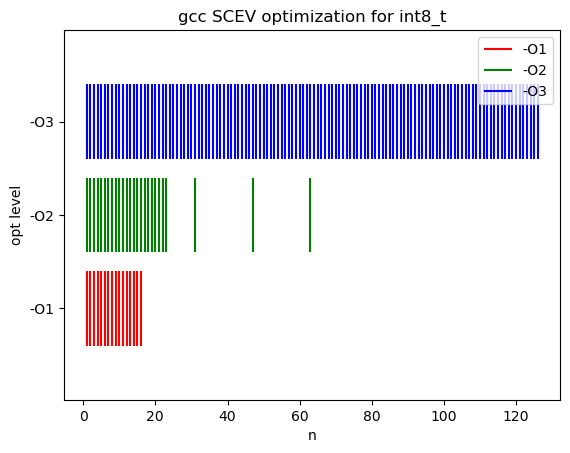

In [4]:
plot_sweep('gcc', I8)

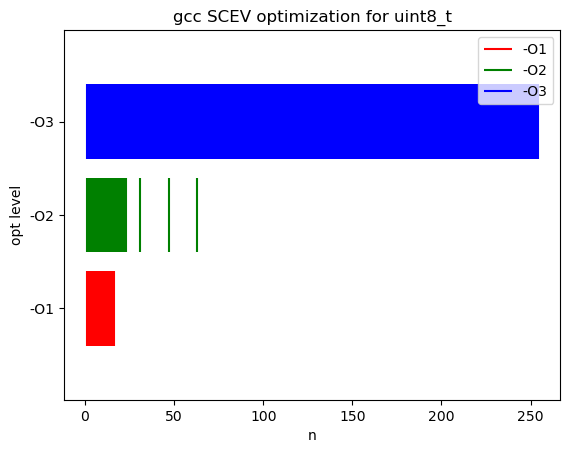

In [5]:
plot_sweep('gcc', U8)

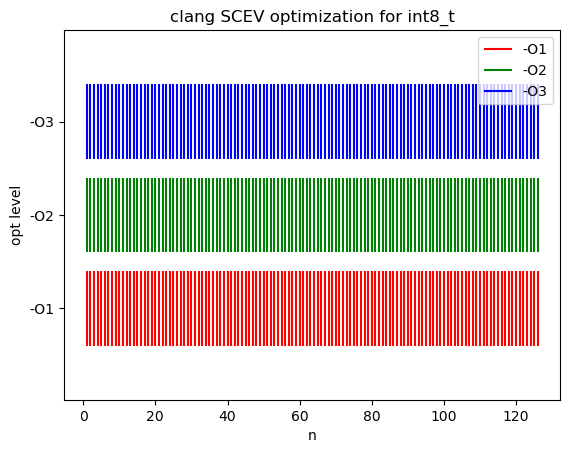

In [6]:
plot_sweep('clang', I8)

## Finding the inflection point
The following analysis assumes there are no holes in the sweep plot. If the case for $n$ is optimized, then we assume that every case for $m$ when $m < n$ is optimized.

We can experimentally find at what point the compiler fails to optimize via a binary search. Then we can infer some properties about the optimization procedure.

In [7]:
def binary_search_inflection(compiler: Compiler, itype: IntType) -> int:
    low, high = 0, itype.intmax()-1
    pred = lambda n: detect_optimization(compiler, itype, n)

    if not pred(low):
        return None
    
    while high-low > 1:
        mid = (low + high) // 2
        assert(low < mid < high)

        if pred(mid): low = mid
        else: high = mid

    assert pred(low)

    if pred(high):
        assert(low+1 == high)
        low = high

    return low

In [8]:
def print_inflection(compiler: Compiler):
    print(f'{compiler.compiler} at {compiler.opt}')

    compute_inflection = partial(binary_search_inflection, compiler)
    itypes = [I8, U8, I16, U16, I32, U32, I64, U64]

    with Pool() as pool:
        inflections = pool.map(compute_inflection, itypes)

    for itype, inflection in zip(itypes, inflections):
        if inflection is None:
            expected_sum = None
            representable = None
        else:
            expected_sum = sum_of_naturals(inflection)
            representable = expected_sum <= itype.intmax()

        print(itype.typename, inflection, expected_sum, representable)

In [9]:
print_inflection(Compiler('gcc', '-O1'))

gcc at -O1
int8_t 16 136 False
uint8_t 16 136 True
int16_t 16 136 True
uint16_t 16 136 True
int32_t 16 136 True
uint32_t 16 136 True
int64_t 16 136 True
uint64_t 16 136 True


In [10]:
print_inflection(Compiler('gcc', '-O2'))

gcc at -O2
int8_t 63 2016 False
uint8_t 63 2016 False
int16_t 362 65703 False
uint16_t 362 65703 False
int32_t 92682 4295022903 False
uint32_t 92682 4295022903 False
int64_t 6074001000 18446744077037500500 False
uint64_t 6074001000 18446744077037500500 False


In [11]:
print_inflection(Compiler('gcc', '-O3', enable_warnings=True))

gcc at -O3
int8_t 126 8001 False
uint8_t 254 32385 False
int16_t 362 65703 False
uint16_t 362 65703 False
int32_t 92682 4295022903 False
uint32_t 92682 4295022903 False
int64_t 6074001000 18446744077037500500 False
uint64_t 6074001000 18446744077037500500 False


These results have been validated against manual experiments on godbolt